In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks


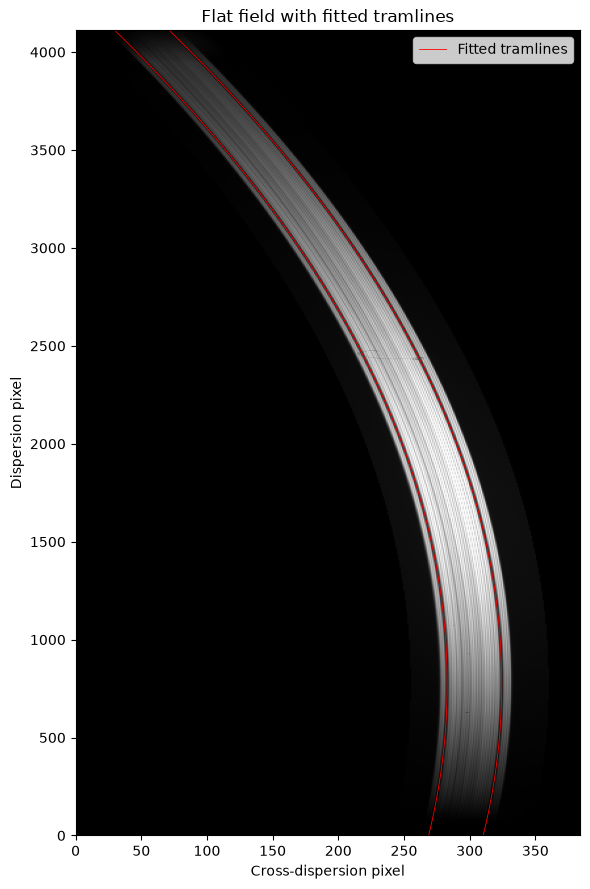

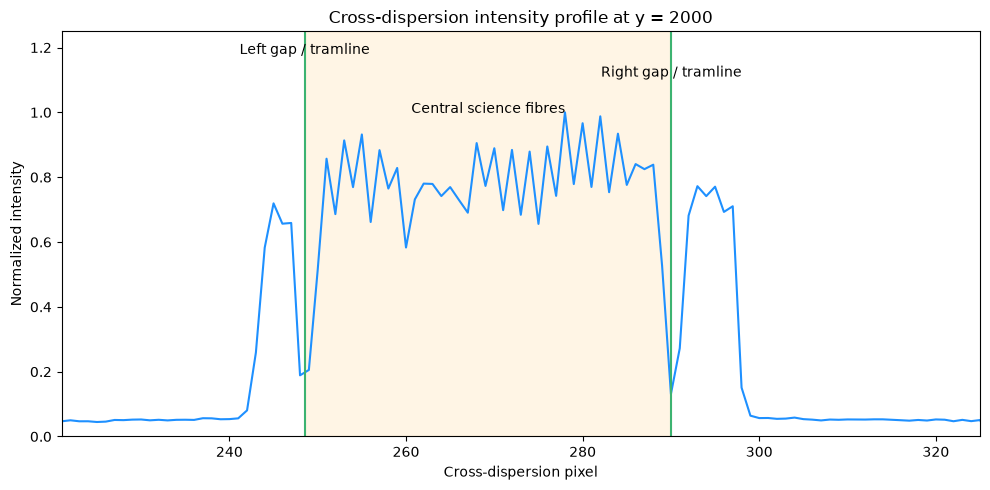

I determined the tramlines by fitting Gaussian centres to the cross dispersion profiles, aligning the rows to identify the two persistent low illumination gaps, and fitting their midpoint with a polynomial while keeping their mean separation fixed.


In [7]:
# Define the Gaussian model
def gaussian(x, amplitude, centre, sigma, background):
    return background + amplitude * np.exp(-0.5 * ((x - centre) / sigma) ** 2)


# Read the flat-field image
flat_path = "/g/data/qp00/sz4640/ASTR_computing/Assugnment2/astro_comp_assignment02_2026/data/flat.fits"
flat = fits.getdata(flat_path)

ny, nx = flat.shape
x_pixels = np.arange(nx)


# Select rows containing a complete spectral order
non_zero = flat > 0
row_widths = np.count_nonzero(non_zero, axis=1)
usual_width = np.bincount(row_widths).argmax()
good_rows = (row_widths == usual_width) & (flat.max(axis=1) > 0.05 * flat.max())
selected_rows = np.where(good_rows)[0]


# Fit a Gaussian envelope to each selected row
gaussian_rows = []
gaussian_centres = []

for y in selected_rows:
    row = flat[y]
    positive_pixels = np.flatnonzero(row > 0)
    x_min = positive_pixels[0]
    x_max = positive_pixels[-1]

    x = np.arange(x_min, x_max + 1)
    intensity = row[x_min:x_max + 1]
    smooth_intensity = gaussian_filter1d(intensity, sigma=3)

    background_guess = smooth_intensity.min()
    amplitude_guess = smooth_intensity.max() - background_guess
    centre_guess = x[np.argmax(smooth_intensity)]
    sigma_guess = 25

    parameters, _ = curve_fit(gaussian, x, smooth_intensity, p0=[amplitude_guess, centre_guess, sigma_guess, background_guess], bounds=([0, x_min, 5, 0], [np.inf, x_max, 80, np.inf]), maxfev=5000)
    gaussian_rows.append(y)
    gaussian_centres.append(parameters[1])

gaussian_rows = np.array(gaussian_rows)
gaussian_centres = np.array(gaussian_centres)


# Fit a smooth curve through the Gaussian centres
centre_coefficients = np.polyfit(gaussian_rows, gaussian_centres, 4)
smooth_gaussian_centres = np.polyval(centre_coefficients, gaussian_rows)


# Align all profiles using the Gaussian centres
relative_step = 0.25
relative_x = np.arange(-45, 45 + relative_step, relative_step)
aligned_profiles = []

for y, centre in zip(gaussian_rows, smooth_gaussian_centres):
    normalized_row = flat[y] / flat[y].max()
    aligned_profile = np.interp(centre + relative_x, x_pixels, normalized_row)
    aligned_profiles.append(aligned_profile)

aligned_profiles = np.array(aligned_profiles)
median_profile = np.median(aligned_profiles, axis=0)
median_profile = gaussian_filter1d(median_profile, sigma=1)


# Find the two strongest low-illumination gaps
gap_peaks, properties = find_peaks(-median_profile, distance=int(15 / relative_step), prominence=0.1)

if len(gap_peaks) < 2:
    raise RuntimeError("Could not identify two low-illumination gaps.")

strongest_gaps = np.argsort(properties["prominences"])[-2:]
gap_offsets = np.sort(relative_x[gap_peaks[strongest_gaps]])


# Measure the exact gap positions in each row
left_gap = []
right_gap = []
half_window = 4

for y, centre in zip(gaussian_rows, smooth_gaussian_centres):
    row = flat[y]
    left_guess = int(round(centre + gap_offsets[0]))
    right_guess = int(round(centre + gap_offsets[1]))

    left_start = left_guess - half_window
    left_end = left_guess + half_window + 1
    left_position = left_start + np.argmin(row[left_start:left_end])

    right_start = right_guess - half_window
    right_end = right_guess + half_window + 1
    right_position = right_start + np.argmin(row[right_start:right_end])

    left_gap.append(left_position)
    right_gap.append(right_position)

left_gap = np.array(left_gap)
right_gap = np.array(right_gap)


# Fit the two tramlines with a constant separation
separation = np.mean(right_gap - left_gap)
gap_centre = (left_gap + right_gap) / 2
tramline_coefficients = np.polyfit(gaussian_rows, gap_centre, 4)

y_plot = np.arange(ny)
fitted_gap_centre = np.polyval(tramline_coefficients, y_plot)
tramline1 = fitted_gap_centre - separation / 2
tramline2 = fitted_gap_centre + separation / 2


# Plot and save the flat field with the fitted tramlines
fig1, ax1 = plt.subplots(figsize=(6, 9))

ax1.imshow(flat, origin="lower", cmap="gray", aspect="auto", vmin=0, vmax=np.percentile(flat[flat > 0], 99))
ax1.plot(tramline1, y_plot, color="red", linewidth=0.6, label="Fitted tramlines")
ax1.plot(tramline2, y_plot, color="red", linewidth=0.6)

ax1.set_xlabel("Cross-dispersion pixel")
ax1.set_ylabel("Dispersion pixel")
ax1.set_title("Flat field with fitted tramlines")
ax1.set_xlim(0, nx - 1)
ax1.set_ylim(0, ny - 1)
ax1.legend()

plt.tight_layout()

output_path = "/g/data/qp00/sz4640/ASTR_computing/Assugnment2/astro_comp_assignment02_2026/figures/Q4.1.png"
plt.savefig(output_path, dpi=300)
plt.show()


# Display one cross-dispersion profile for illustratinh my method
example_y = 2000
profile = flat[example_y].astype(float)
profile = profile / profile.max()

left_position = tramline1[example_y]
right_position = tramline2[example_y]

positive_pixels = np.flatnonzero(flat[example_y] > 0)
x_min = positive_pixels[0]
x_max = positive_pixels[-1]

fig2, ax2 = plt.subplots(figsize=(10, 5))

ax2.plot(x_pixels, profile, color="dodgerblue", linewidth=1.5)
ax2.axvspan(left_position, right_position, color="orange", alpha=0.10)
ax2.axvline(left_position, color="mediumseagreen", linewidth=1.5)
ax2.axvline(right_position, color="mediumseagreen", linewidth=1.5)

ax2.text(left_position, 1.17, "Left gap / tramline", ha="center", va="bottom")
ax2.text(right_position, 1.10, "Right gap / tramline", ha="center", va="bottom")
ax2.text((left_position + right_position) / 2, 1.01, "Central science fibres", ha="center", va="center")

ax2.set_xlabel("Cross-dispersion pixel")
ax2.set_ylabel("Normalized intensity")
ax2.set_title(f"Cross-dispersion intensity profile at y = {example_y}")
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 1.25)

plt.tight_layout()
plt.show()

print("I determined the tramlines by fitting Gaussian centres to the cross dispersion profiles, aligning the rows to identify the two persistent low illumination gaps, and fitting their midpoint with a polynomial while keeping their mean separation fixed.")

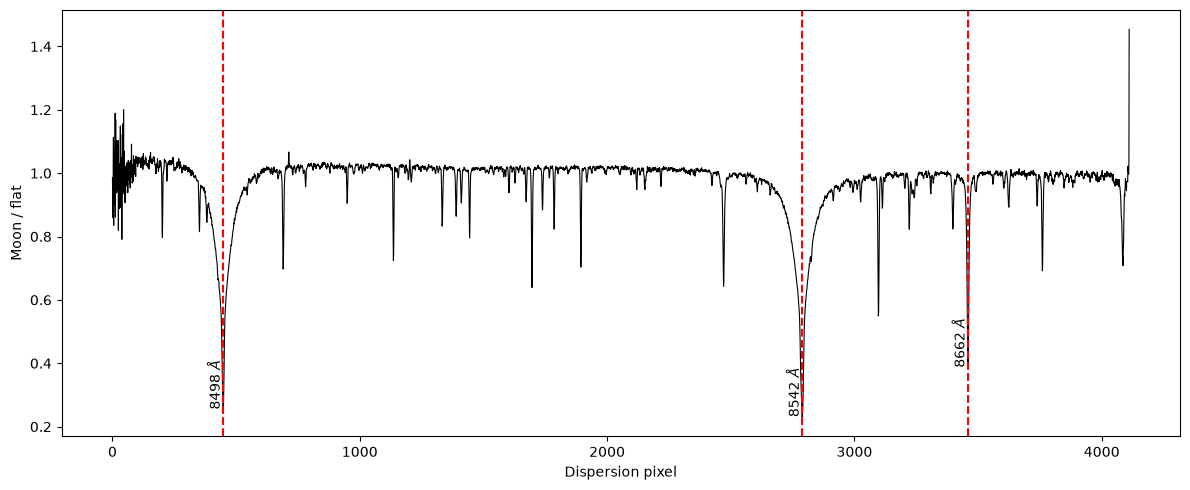

Ca II pixel positions: [ 448 2789 3459]


In [ ]:
# Q2 first find the absorption band
# Read the Moon image
# Read the Moon image
moon_path = "/g/data/qp00/sz4640/ASTR_computing/Assugnment2/astro_comp_assignment02_2026/data/moon.fits"
moon = fits.getdata(moon_path).astype(float)


# Sum the counts between the tramlines
flat_spectrum = np.zeros(flat.shape[0])
moon_spectrum = np.zeros(moon.shape[0])

for y in range(flat.shape[0]):
    x_left = int(np.ceil(tramline1[y]))
    x_right = int(np.floor(tramline2[y])) + 1
    flat_spectrum[y] = np.sum(flat[y, x_left:x_right])
    moon_spectrum[y] = np.sum(moon[y, x_left:x_right])


# Divide Moon by flat
corrected_spectrum = moon_spectrum / flat_spectrum
corrected_spectrum /= np.nanmedian(corrected_spectrum)

pixels = np.arange(len(corrected_spectrum))


# Find the three strongest absorption lines without smoothing
absorption_pixels, properties = find_peaks(
    -corrected_spectrum,
    prominence=0.02,
    distance=20
)

strongest = np.argsort(properties["prominences"])[-3:]
ca_pixels = np.sort(absorption_pixels[strongest])
ca_wavelengths = [8498, 8542, 8662]


# Plot the spectrum and Ca II positions
plt.figure(figsize=(12, 5))
plt.plot(pixels, corrected_spectrum, color="black", linewidth=0.8)

for wavelength, pixel in zip(ca_wavelengths, ca_pixels):
    plt.axvline(pixel, color="red", linestyle="--")
    plt.text(
        pixel,
        corrected_spectrum[pixel],
        rf"{wavelength} $\AA$",
        rotation=90,
        ha="right",
        va="bottom"
    )

plt.xlabel("Dispersion pixel")
plt.ylabel("Moon / flat")
plt.tight_layout()
plt.show()

print("Ca II pixel positions:", ca_pixels)

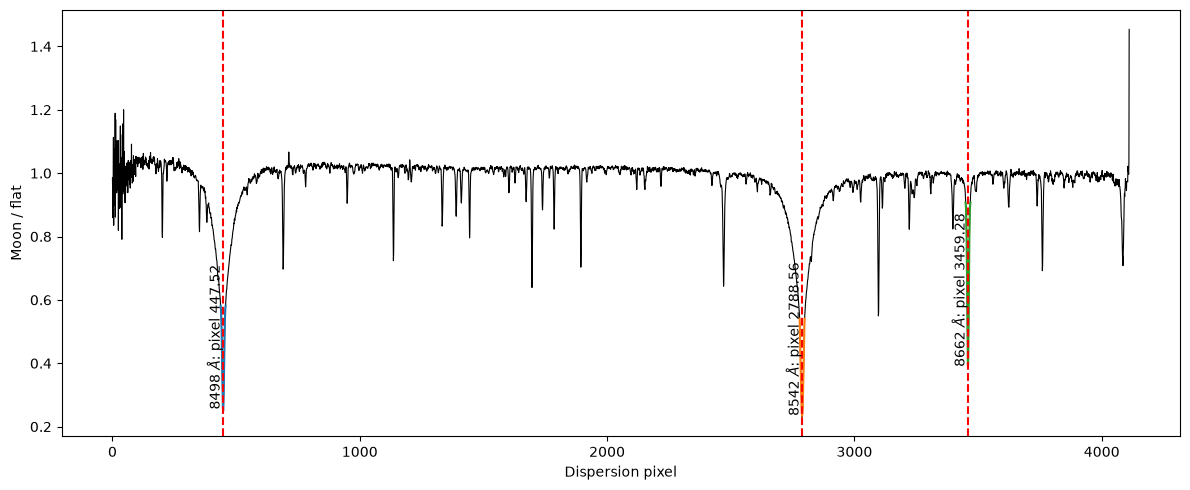

Ca II 8498 Å: pixel = 447.52
Ca II 8542 Å: pixel = 2788.56
Ca II 8662 Å: pixel = 3459.28


In [14]:
fitted_pixels = []
fit_results = []
half_window = 10

for guess in ca_pixels:
    mask = (pixels >= guess - half_window) & (pixels <= guess + half_window) & np.isfinite(corrected_spectrum)
    x_line = pixels[mask]
    y_line = corrected_spectrum[mask]

    background_guess = np.median(y_line)
    amplitude_guess = np.min(y_line) - background_guess
    centre_guess = x_line[np.argmin(y_line)]
    sigma_guess = 2

    parameters, _ = curve_fit(gaussian, x_line, y_line, p0=[amplitude_guess, centre_guess, sigma_guess, background_guess], bounds=([-np.inf, guess - half_window, 0.2, -np.inf], [0, guess + half_window, half_window, np.inf]), maxfev=10000)

    fitted_pixels.append(parameters[1])
    fit_results.append(parameters)

plt.figure(figsize=(12, 5))
plt.plot(pixels, corrected_spectrum, color="black", linewidth=0.8)

for wavelength, centre, parameters in zip(ca_wavelengths, fitted_pixels, fit_results):
    x_fit = np.linspace(centre - half_window, centre + half_window, 200)
    plt.plot(x_fit, gaussian(x_fit, *parameters), linewidth=1.5)
    plt.axvline(centre, color="red", linestyle="--")
    plt.text(centre, np.interp(centre, pixels, corrected_spectrum), rf"{wavelength} $\AA$: pixel {centre:.2f}", rotation=90, ha="right", va="bottom")
    
plt.xlabel("Dispersion pixel")
plt.ylabel("Moon / flat")
plt.tight_layout()

output_path = "/g/data/qp00/sz4640/ASTR_computing/Assugnment2/astro_comp_assignment02_2026/figures/Q4.2.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

for wavelength, centre in zip(ca_wavelengths, fitted_pixels):
    print(f"Ca II {wavelength} Å: pixel = {centre:.2f}")